<a href="https://colab.research.google.com/github/stnguswnd/LLM_Agent_Colab/blob/main/260601_langgraph_multi_agent_collaboration_%EC%A3%BC%EC%8B%9D_%EA%B0%80%EA%B2%A9_%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Multi-agent Collaboration를 이용한 주식 가격 시각화 AI 에이전트 만들기
## 작성자 : AISchool ( http://aischool.ai/%ec%98%a8%eb%9d%bc%ec%9d%b8-%ea%b0%95%ec%9d%98-%ec%b9%b4%ed%85%8c%ea%b3%a0%eb%a6%ac/ )
## Reference : https://langchain-ai.github.io/langgraph/tutorials/multi_agent/multi-agent-collaboration/

하나의 에이전트는 일반적으로 단일 도메인 내에서 소수의 도구만으로도 효과적으로 작동할 수 있습니다. 그러나 GPT-4와 같은 강력한 모델을 사용하더라도 많은 도구를 사용할 때는 덜 효과적일 수 있습니다.

복잡한 작업에 접근하는 한 가지 방법은 **"분할 정복"(divide-and-conquer) 접근법**입니다. **각 작업이나 도메인에 특화된 에이전트를 생성하고 작업을 올바른 "전문가"에게 라우팅**하는 방식입니다.

이 예제는 Wu 외 연구진이 작성한 논문 AutoGen: Enabling Next-Gen LLM Applications via Multi-Agent Conversation ( https://arxiv.org/abs/2308.08155 )에서 영감을 받아 이를 LangGraph를 사용하여 구현하는 방법을 보여줍니다.

결과 그래프는 다음 다이어그램과 유사한 형태가 될 것입니다.









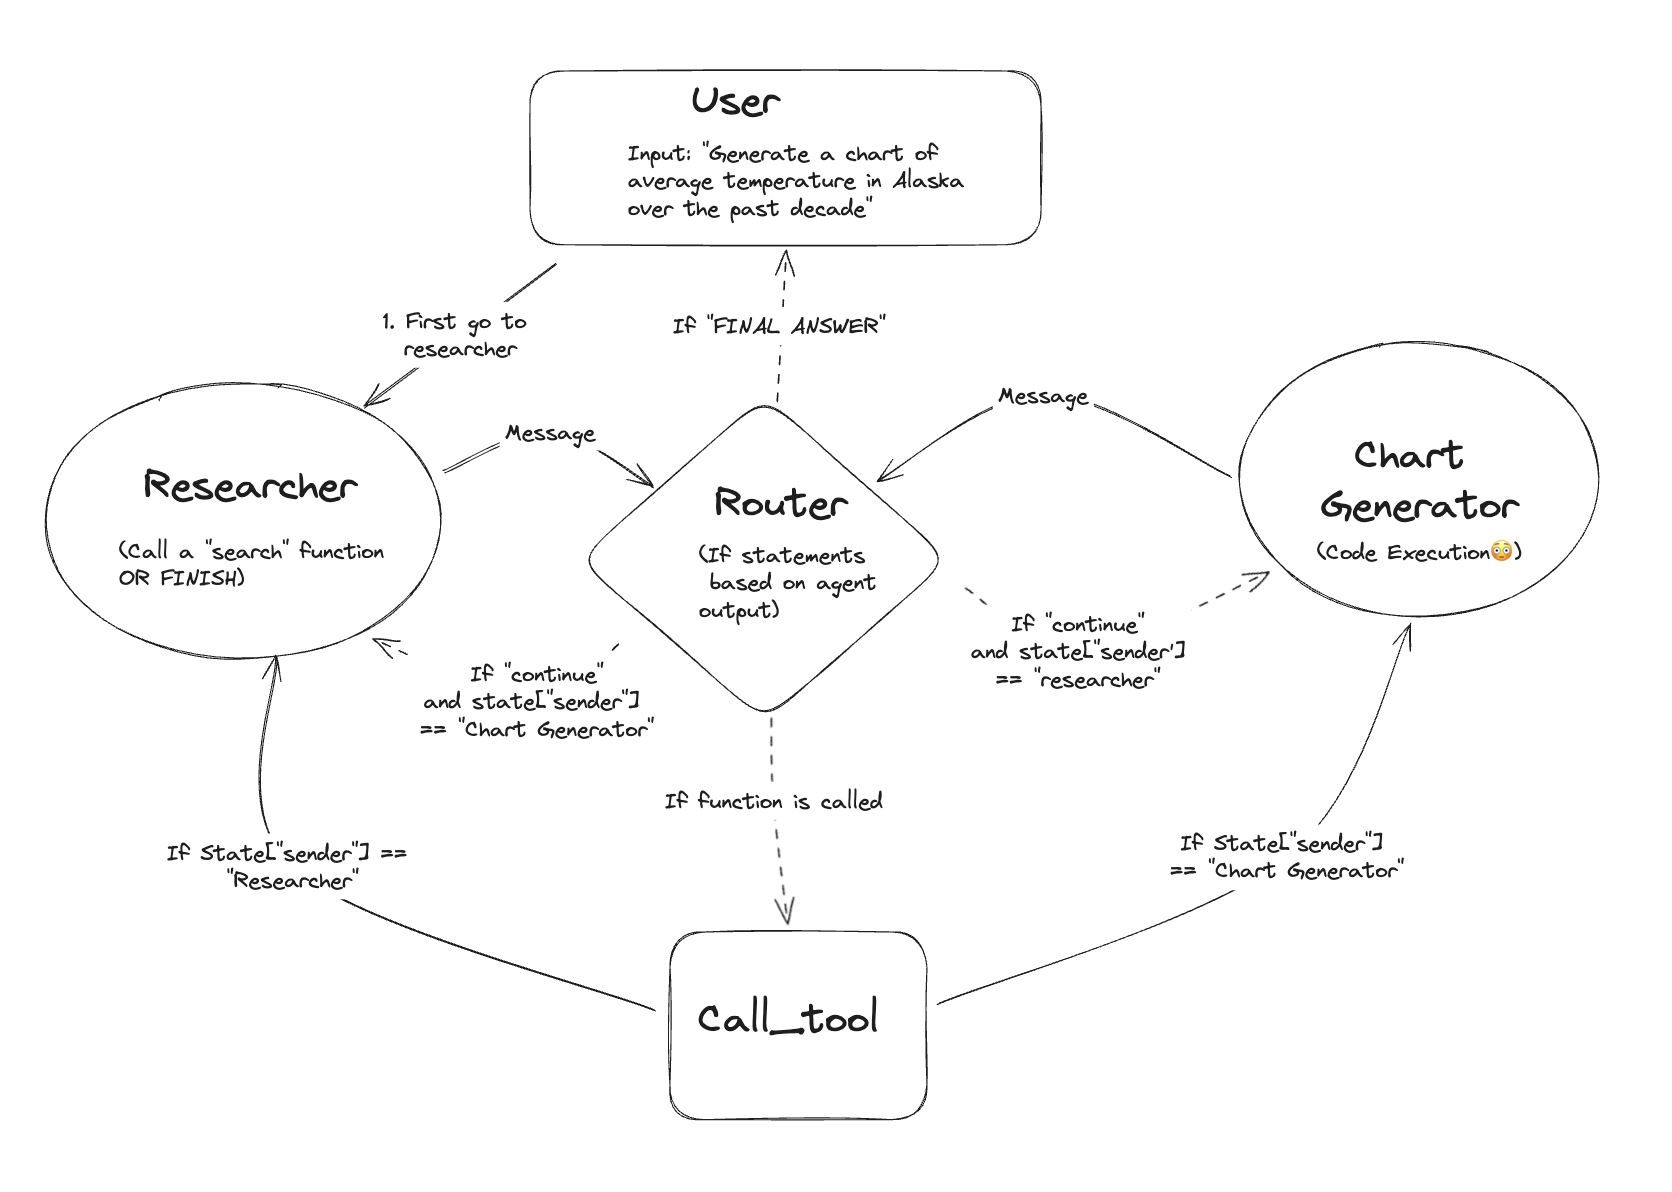

시작하기 전에 간단한 주의 사항입니다: 이 노트북과 다른 다중 에이전트 노트북들은 LangGraph에서 특정 디자인 패턴을 구현하는 방법을 보여주기 위해 설계되었습니다. 이 패턴이 귀하의 필요에 맞는다면, 최상의 성능을 위해 문서의 다른 기본 패턴들과 결합하여 사용하는 것을 권장합니다.









# 라이브러리 설치

In [ ]:
!pip install langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core duckduckgo-search langchain-community

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.1/208.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.8/401.8 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.0/78.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/

In [ ]:
# 주식 가격 크롤링을 위한 finance-datareader 라이브러리 설치
!pip install finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/89.3 kB 2.6 MB/s eta 0:00:00


# API Key 설정

In [ ]:
import os
from uuid import uuid4

unique_id = uuid4().hex[0:8]
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"Basic Multi-agent Collaboration - Stock Price Visualization - {unique_id}"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = "여러분의_LANGCHAIN_API_KEY"

In [ ]:
unique_id

'30cb654d'

In [ ]:
os.environ["OPENAI_API_KEY"] = "여러분의_OPENAI_API_KEY"

# Create Agents


다음 보조 함수들은 에이전트를 생성하는 데 도움을 줄 것입니다. 이러한 에이전트들은 그래프의 노드가 됩니다.

그래프가 어떻게 생겼는지 바로 보고 싶다면 이 부분을 건너뛰어도 됩니다.

In [ ]:
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    ToolMessage,
)
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

from langgraph.graph import END, StateGraph, START


def create_agent(llm, tools, system_message: str):
    """Create an agent."""
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant, collaborating with other assistants."
                " Use the provided tools to progress towards answering the question."
                " If you are unable to fully answer, that's OK, another assistant with different tools "
                " will help where you left off. Execute what you can to make progress."
                " If you or any of the other assistants have the final answer or deliverable,"
                " prefix your response with FINAL ANSWER so the team knows to stop."
                " You have access to the following tools: {tool_names}.\n{system_message}",
            ),
            MessagesPlaceholder(variable_name="messages"),
        ]
    )
    prompt = prompt.partial(system_message=system_message)
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    return prompt | llm.bind_tools(tools)

In [ ]:
# "당신은 다른 AI 어시스턴트들과 협력하는 유용한 AI 어시스턴트입니다."
# "질문에 답을 진행하기 위해 제공된 도구들을 사용하세요."
# "만약 질문에 완전히 답하지 못하더라도 괜찮습니다. 다른 도구를 가진 또 다른 어시스턴트가"
# "당신이 멈춘 부분을 도울 것입니다. 할 수 있는 만큼 실행하여 진전을 이루세요."
# "만약 당신이나 다른 어시스턴트가 최종 답변이나 결과물을 가지고 있다면,"
# "응답의 시작에 'FINAL ANSWER'라고 표기하여 팀이 멈추도록 하세요."
# "당신은 다음 도구들에 접근할 수 있습니다: {tool_names}.\n{system_message}"

# Define tools


또한 나중에 에이전트들이 사용할 몇 가지 도구도 정의할 것입니다.


## finance-datareader를 이용한 주식가격 크롤링 tool 정의

In [ ]:
from langchain_core.tools import tool
import FinanceDataReader as fdr
import pandas as pd

@tool
def get_stock_data(symbol: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    주어진 종목 코드(symbol)와 기간(start_date, end_date) 동안의 주가 데이터를 반환하는 함수.

    Parameters:
    - symbol (str): 종목 코드 (예: 'AAPL', '005930')
    - start_date (str): 시작 날짜 (YYYY-MM-DD 형식)
    - end_date (str): 끝 날짜 (YYYY-MM-DD 형식)

    Returns:
    - DataFrame: 주가 데이터 (날짜별 시가, 고가, 저가, 종가, 거래량 등)
    """
    # FDR을 사용하여 주가 데이터를 가져옴
    df = fdr.DataReader(symbol, start_date, end_date)

    # 가져온 데이터프레임 반환
    return df

In [ ]:
print(get_stock_data.name)
print(get_stock_data.description)
print(get_stock_data.args)

get_stock_data
주어진 종목 코드(symbol)와 기간(start_date, end_date) 동안의 주가 데이터를 반환하는 함수.

Parameters:
- symbol (str): 종목 코드 (예: 'AAPL', '005930')
- start_date (str): 시작 날짜 (YYYY-MM-DD 형식)
- end_date (str): 끝 날짜 (YYYY-MM-DD 형식)

Returns:
- DataFrame: 주가 데이터 (날짜별 시가, 고가, 저가, 종가, 거래량 등)
{'symbol': {'title': 'Symbol', 'type': 'string'}, 'start_date': {'title': 'Start Date', 'type': 'string'}, 'end_date': {'title': 'End Date', 'type': 'string'}}


In [ ]:
# 삼성전자(005930)의 2023년 1월 1일부터 2023년 10월 1일까지의 주가 데이터 가져오기
stock_data = get_stock_data.invoke({"symbol":'005930', "start_date":'2023-01-01', "end_date":'2023-10-01'})

# 출력
print(stock_data)

             Open   High    Low  Close    Volume    Change
Date                                                      
2023-01-02  55500  56100  55200  55500  10031448  0.003617
2023-01-03  55400  56000  54500  55400  13547030 -0.001802
2023-01-04  55700  58000  55600  57800  20188071  0.043321
2023-01-05  58200  58800  57600  58200  15682826  0.006920
2023-01-06  58300  59400  57900  59000  17334989  0.013746
...           ...    ...    ...    ...       ...       ...
2023-09-21  69200  69800  68800  68900  10796336 -0.010057
2023-09-22  68300  68900  68300  68800   9897840 -0.001451
2023-09-25  68500  69700  68500  69400  13582516  0.008721
2023-09-26  70000  70000  68400  68600  13143470 -0.011527
2023-09-27  68600  69100  68200  68400  14886491 -0.002915

[185 rows x 6 columns]


## python REPL을 이용한 차트 생성 tool 정의

In [ ]:
from typing import Annotated
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

# Warning: This executes code locally, which can be unsafe when not sandboxed

repl = PythonREPL()


@tool
def python_repl(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

# Create graph


이제 도구들을 정의하고 보조 함수를 만들었으니, 아래에서 **개별 에이전트들을 생성하고 LangGraph를 사용하여 서로 소통하는 방법**을 알려주겠습니다.

## Define State


먼저 그래프의 상태를 정의합니다. 이는 단순히 메시지 목록과, 가장 최근에 메시지를 보낸 발신자(sender)를 추적하는 키로 구성됩니다.

In [ ]:
import operator
from typing import Annotated, Sequence, TypedDict

from langchain_openai import ChatOpenAI


# This defines the object that is passed between each node
# in the graph. We will create different nodes for each agent and tool
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: str

## Define Agent Nodes

이제 노드를 정의해야 합니다. 먼저, 에이전트들을 위한 노드를 정의하겠습니다.









In [ ]:
import functools

from langchain_core.messages import AIMessage


# Helper function to create a node for a given agent
def agent_node(state, agent, name):
    result = agent.invoke(state)
    # We convert the agent output into a format that is suitable to append to the global state
    if isinstance(result, ToolMessage):
        pass
    else:
        result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)
    return {
        "messages": [result],
        # Since we have a strict workflow, we can
        # track the sender so we know who to pass to next.
        "sender": name,
    }


llm = ChatOpenAI(model="gpt-4o")

## 주식 가격을 크롤링하는 Research Agent 생성

In [ ]:
# Research agent and node
research_agent = create_agent(
    llm,
    [get_stock_data],
    system_message="You should provide stock data for use, "
        "and source code shouldn't be the final answer",
)
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")

## Python 코드 실행기를 사용하는 Chart Agent 생성

In [ ]:
# chart_generator
chart_agent = create_agent(
    llm,
    [python_repl],
    system_message="Run the python code to display the chart.",
)
chart_node = functools.partial(agent_node, agent=chart_agent, name="chart_generator")

# Define Tool Node


이제 도구들을 실행할 노드를 정의하겠습니다.









In [ ]:
from langgraph.prebuilt import ToolNode

tools = [get_stock_data, python_repl]
tool_node = ToolNode(tools)

# Define Edge Logic

이제 에이전트들의 결과에 따라 무엇을 할지 결정하는 데 필요한 일부 엣지 로직을 정의할 수 있습니다.









In [ ]:
# Either agent can decide to end
from typing import Literal


def router(state) -> Literal["call_tool", "__end__", "continue"]:
    # This is the router
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        # The previous agent is invoking a tool
        return "call_tool"
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return "__end__"
    return "continue"

# Define the Graph

이제 모든 것을 합쳐서 그래프를 정의할 수 있습니다!









In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("Researcher", research_node)
workflow.add_node("chart_generator", chart_node)
workflow.add_node("call_tool", tool_node)

workflow.add_conditional_edges(
    "Researcher",
    router,
    {"continue": "chart_generator", "call_tool": "call_tool", "__end__": END},
)
workflow.add_conditional_edges(
    "chart_generator",
    router,
    {"continue": "Researcher", "call_tool": "call_tool", "__end__": END},
)

workflow.add_conditional_edges(
    "call_tool",
    # Each agent node updates the 'sender' field
    # the tool calling node does not, meaning
    # this edge will route back to the original agent
    # who invoked the tool
    lambda x: x["sender"],
    {
        "Researcher": "Researcher",
        "chart_generator": "chart_generator",
    },
)
workflow.add_edge(START, "Researcher")
graph = workflow.compile()

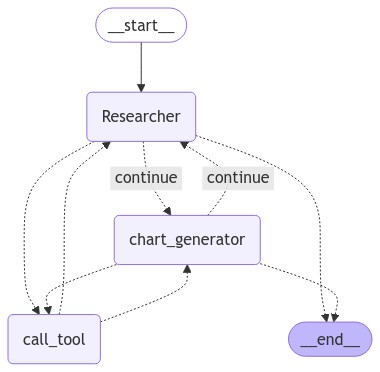

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


# Invoke

그래프가 생성되었으니 이제 실행할 수 있습니다! 몇 가지 통계를 차트로 표시해 보겠습니다.

{'Researcher': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_5YmU9ef0tAq8KfPPzMzkppLV', 'function': {'arguments': '{"symbol":"005930","start_date":"2023-01-05","end_date":"2023-01-20"}', 'name': 'get_stock_data'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 299, 'total_tokens': 335, 'completion_tokens_details': {'audio_tokens': None, 'reasoning_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e5e4913e83', 'finish_reason': 'tool_calls', 'logprobs': None}, name='Researcher', id='run-e57e1fe7-b235-4247-acb6-f4f81c068eb2-0', tool_calls=[{'name': 'get_stock_data', 'args': {'symbol': '005930', 'start_date': '2023-01-05', 'end_date': '2023-01-20'}, 'id': 'call_5YmU9ef0tAq8KfPPzMzkppLV', 'type': 'tool_call'}], usage_metadata={'input_tokens': 299, 'output_tokens': 36, 'total_tokens': 335, 'inp

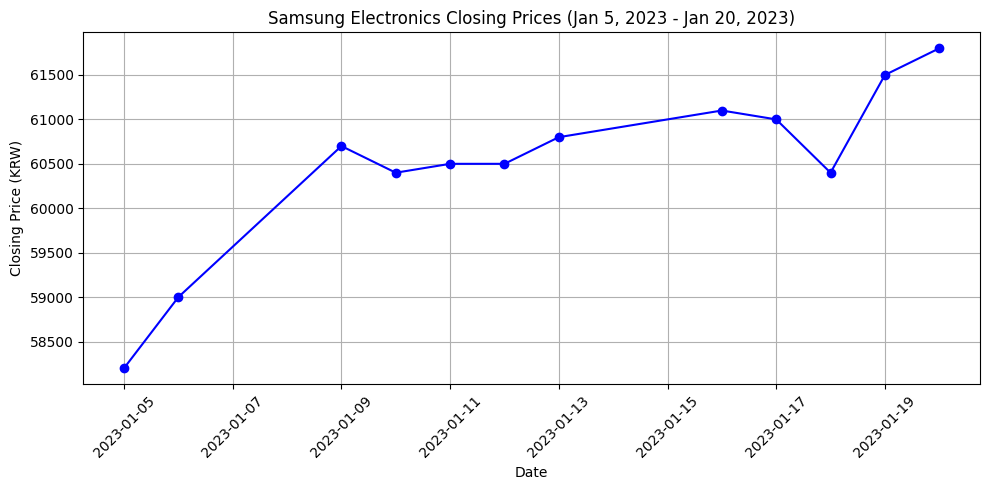

{'call_tool': {'messages': [ToolMessage(content='Successfully executed:\n```python\nimport matplotlib.pyplot as plt\nimport pandas as pd\nfrom io import StringIO\n\n# 삼성전자의 주가 데이터\ndata = """\nDate,Open,High,Low,Close,Volume,Change\n2023-01-05,58200,58800,57600,58200,15682826,0.006920\n2023-01-06,58300,59400,57900,59000,17334989,0.013746\n2023-01-09,59700,60700,59600,60700,18640107,0.028814\n2023-01-10,60200,61100,59900,60400,14859797,-0.004942\n2023-01-11,61000,61200,60300,60500,12310751,0.001656\n2023-01-12,61100,61200,59900,60500,16102561,0.000000\n2023-01-13,60500,61200,60400,60800,12510328,0.004959\n2023-01-16,61300,61600,60800,61100,10039972,0.004934\n2023-01-17,61200,61500,60600,61000,9831456,-0.001637\n2023-01-18,60700,61000,59900,60400,11584041,-0.009836\n2023-01-19,60500,61500,60400,61500,12808490,0.018212\n2023-01-20,62100,62300,61100,61800,9646327,0.004878\n"""\n\n# 데이터 프레임으로 변환\ndf = pd.read_csv(StringIO(data), parse_dates=[\'Date\'], index_col=\'Date\')\n\n# 종가 그래프 그리기\np

In [ ]:
events = graph.stream(
    {
        "messages": [
            HumanMessage(
                content="삼성전자의 2023년 1월 5일부터 2023년 1월 20일까지의 종가를 그래프로 그려줘"
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 10},
)
for s in events:
    print(s)
    print("----")

{'Researcher': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_mje5Tmbgz6b9WZSrktzwdC6U', 'function': {'arguments': '{"symbol":"066570","start_date":"2022-12-01","end_date":"2022-12-15"}', 'name': 'get_stock_data'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 298, 'total_tokens': 334, 'completion_tokens_details': {'audio_tokens': None, 'reasoning_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e5e4913e83', 'finish_reason': 'tool_calls', 'logprobs': None}, name='Researcher', id='run-5f237caf-1bca-494f-af98-57968efed6b5-0', tool_calls=[{'name': 'get_stock_data', 'args': {'symbol': '066570', 'start_date': '2022-12-01', 'end_date': '2022-12-15'}, 'id': 'call_mje5Tmbgz6b9WZSrktzwdC6U', 'type': 'tool_call'}], usage_metadata={'input_tokens': 298, 'output_tokens': 36, 'total_tokens': 334, 'inp

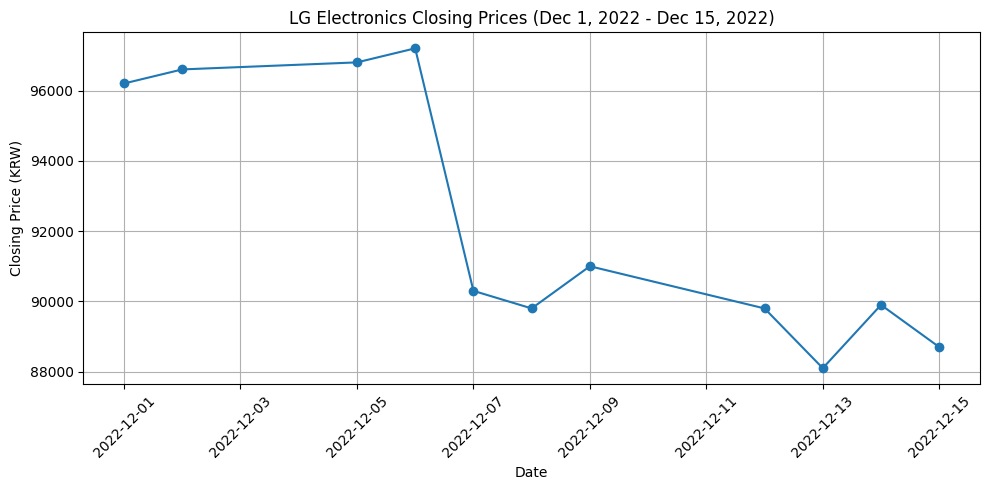

{'call_tool': {'messages': [ToolMessage(content='Successfully executed:\n```python\nimport matplotlib.pyplot as plt\nimport pandas as pd\n\n# 주어진 데이터\ndata = {\n    "Date": [\n        "2022-12-01", "2022-12-02", "2022-12-05", "2022-12-06", "2022-12-07",\n        "2022-12-08", "2022-12-09", "2022-12-12", "2022-12-13", "2022-12-14", "2022-12-15"\n    ],\n    "Close": [\n        96200, 96600, 96800, 97200, 90300,\n        89800, 91000, 89800, 88100, 89900, 88700\n    ]\n}\n\n# 데이터프레임 생성\ndf = pd.DataFrame(data)\ndf["Date"] = pd.to_datetime(df["Date"])  # 날짜 형식 변환\n\n# 그래프 그리기\nplt.figure(figsize=(10, 5))\nplt.plot(df["Date"], df["Close"], marker=\'o\', linestyle=\'-\')\nplt.title("LG Electronics Closing Prices (Dec 1, 2022 - Dec 15, 2022)")\nplt.xlabel("Date")\nplt.ylabel("Closing Price (KRW)")\nplt.grid(True)\nplt.xticks(rotation=45)\nplt.tight_layout()\nplt.show()\n```\nStdout: \n\nIf you have completed all tasks, respond with FINAL ANSWER.', name='python_repl', tool_call_id='call_9e7za

In [ ]:
events = graph.stream(
    {
        "messages": [
            HumanMessage(
                content="LG전자의 2022년 12월 1일부터 2022년 12월 15일까지의 종가를 그래프로 그려줘"
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 10},
)
for s in events:
    print(s)
    print("----")